In [ ]:
#trim FP datafile based on timestamps.
import pandas as pd

# === Load CSVs (no header) ===
timestamps = pd.read_csv("/Users/annastuckert/Documents/GitHub/FP_behaviour_analysis/file_name_timestamp0.csv", header=None, sep=",")
fp_data = pd.read_csv("/Users/annastuckert/Documents/GitHub/FP_behaviour_analysis/test_FP0.csv")

# === Name columns in timestamps file ===
# Based on your description:
# Col 0: Input1, Col 1: ?, Col 2: ?, Col 3: timestamp, Col 4: ?
timestamps.columns = ["Input", "Col1", "Bool", "Timestamp", "Other"]

# --- Extract start and stop timestamps ---
start_time = timestamps.loc[0, "Timestamp"]
stop_time = timestamps.loc[1, "Timestamp"]

# --- Ensure FP data is sorted by SystemTimestamp ---
fp_data = fp_data.sort_values(by="SystemTimestamp").reset_index(drop=True)

# --- Find nearest preceding timestamps ---
fp_start_idx = fp_data[fp_data["SystemTimestamp"] <= start_time]["SystemTimestamp"].idxmax()
fp_stop_idx = fp_data[fp_data["SystemTimestamp"] <= stop_time]["SystemTimestamp"].idxmax()

# --- Slice the data ---
fp_trimmed = fp_data.loc[fp_start_idx:fp_stop_idx].reset_index(drop=True)

# --- Save the trimmed data ---
fp_trimmed.to_csv("test_FP0_trimmed.csv", index=False)

print(f"Start timestamp: {start_time}")
print(f"Stop timestamp:  {stop_time}")
print(f"Trimmed data saved to 'test_FP0_trimmed.csv'")


TypeError: Invalid comparison between dtype=float64 and str

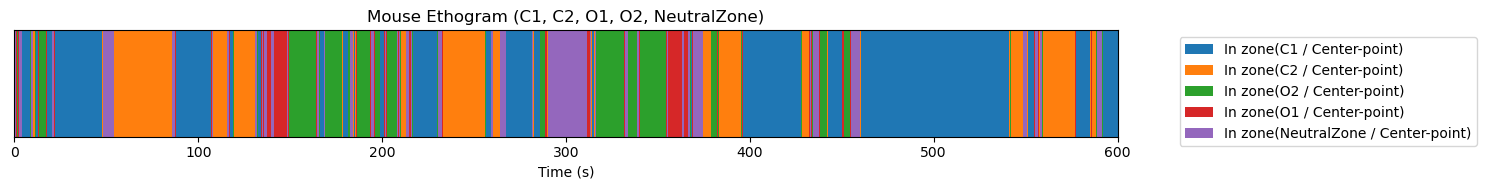

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

file_path = "/Users/annastuckert/Documents/GitHub/FP_behaviour_analysis/Raw data-EPM_postinduction_W2-Trial     8.xlsx"

# Load Excel, skip metadata
df = pd.read_excel(file_path, header=37)

# Zones of interest
zone_columns = [
    "In zone(C1 / Center-point)",
    "In zone(C2 / Center-point)",
    "In zone(O2 / Center-point)",
    "In zone(O1 / Center-point)",
    "In zone(NeutralZone / Center-point)"
]

# Determine current zone
def get_zone(row):
    for col in zone_columns:
        if row[col] == 1:
            return col
    return np.nan  # ignore Arena-only frames

df['Zone'] = df.apply(get_zone, axis=1)

# Map zones to numbers
zone_to_num = {zone: i for i, zone in enumerate(zone_columns)}
df['Zone_num'] = df['Zone'].map(lambda z: zone_to_num[z] if pd.notna(z) else np.nan)

# Ensure Trial time is numeric
df['Trial time'] = pd.to_numeric(df['Trial time'], errors='coerce')

# Drop frames where mouse is not in any zone of interest
df_clean = df.dropna(subset=['Zone_num']).reset_index(drop=True)

# Prepare data for imshow
zone_array = df_clean['Zone_num'].values.reshape(1, -1)

# Create color map
cmap = ListedColormap(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])  # C1, C2, O2, O1, Neutral

plt.figure(figsize=(15, 2))
extent = [df_clean['Trial time'].iloc[0], df_clean['Trial time'].iloc[-1], 0, 1]  # x-axis in seconds
plt.imshow(zone_array, aspect='auto', cmap=cmap, extent=extent)
plt.yticks([])  # remove y-axis
plt.xlabel('Time (s)')
plt.title('Mouse Ethogram (C1, C2, O1, O2, NeutralZone)')

# Create legend
legend_elements = [Patch(facecolor=cmap(i), label=list(zone_to_num.keys())[i]) for i in range(len(zone_to_num))]
plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [ ]:

# Load CSVs
timestamps = pd.read_csv("/Users/annastuckert/Documents/GitHub/FP_behaviour_analysis/file_name_timestamp0.csv", header=None, sep=",")
fp_data = pd.read_csv("/Users/annastuckert/Documents/GitHub/FP_behaviour_analysis/test_FP0.csv")

# Name columns
timestamps.columns = ["Input", "Col1", "Bool", "Timestamp", "Other"]

# Start and stop timestamps
start_time = timestamps.loc[0, "Timestamp"]
stop_time  = timestamps.loc[1, "Timestamp"]

# Sort FP data
fp_data = fp_data.sort_values(by="SystemTimestamp").reset_index(drop=True)

# Trim FP data between start and stop
fp_trim = fp_data[(fp_data["SystemTimestamp"] >= start_time) & (fp_data["SystemTimestamp"] <= stop_time)].reset_index(drop=True)

# Assuming df_clean is your ethogram with columns 'Trial time' and 'Zone_num'

# Interpolate ethogram to FP timestamps
# First, create a function to get zone at nearest EthoVision frame
ethovision_times = df_clean['Trial time'].values
ethovision_zones = df_clean['Zone_num'].values

# Use np.searchsorted to find the nearest EthoVision frame for each FP timestamp
fp_times = fp_trim['SystemTimestamp'].values

# Find indices of nearest EthoVision frame
indices = np.searchsorted(ethovision_times, fp_times, side='right') - 1
indices[indices < 0] = 0  # handle edge case

# Assign zone to FP data
fp_trim['Zone_num'] = ethovision_zones[indices]




In [12]:
# Create reverse mapping
num_to_zone = {v: k for k, v in zone_to_num.items()}
fp_trim['Zone'] = fp_trim['Zone_num'].map(num_to_zone)


plt.figure(figsize=(15, 4))

# Plot FP signal
plt.plot(fp_trim['SystemTimestamp'], fp_trim['FP_signal'], color='black', label='FP signal')  # replace 'FP_signal' with your FP column

# Color background according to zone
for zone_id, color in enumerate(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']):  # same colors as ethogram
    mask = fp_trim['Zone_num'] == zone_id
    plt.fill_between(fp_trim['SystemTimestamp'], fp_trim['FP_signal'].min(), fp_trim['FP_signal'].max(),
                     where=mask, color=color, alpha=0.3, step='post')

plt.xlabel('Time (s)')
plt.ylabel('FP signal')
plt.title('FP signal with EthoVision zones')
plt.legend()
plt.show()


KeyError: 'FP_signal'

<Figure size 1500x400 with 0 Axes>